In [2]:
import pandas as pd

In [4]:
df = pd.read_excel("Mall_Customers.xlsx")

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

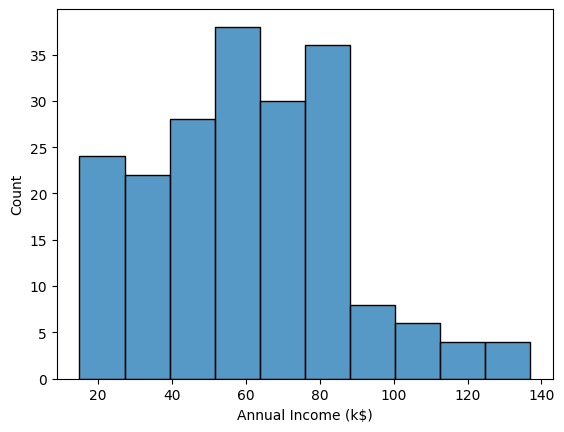

In [12]:
sns.histplot(df['Annual Income (k$)'])
plt.show()

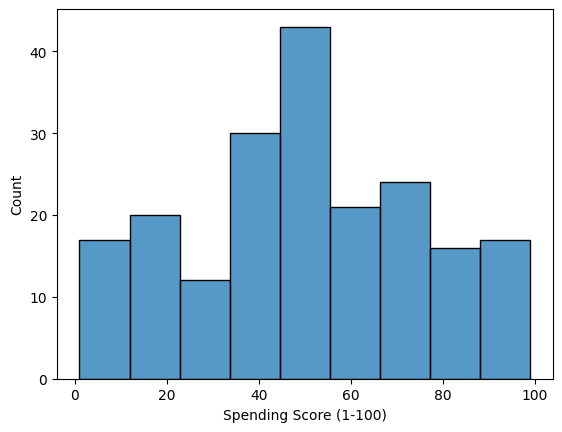

In [13]:
sns.histplot(df['Spending Score (1-100)'])
plt.show()

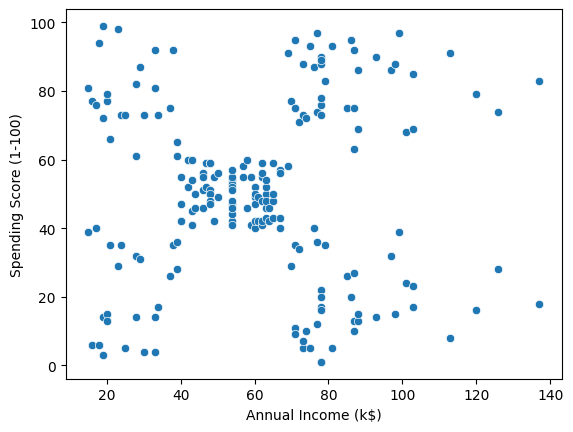

In [15]:
sns.scatterplot(x='Annual Income (k$)',y='Spending Score (1-100)',data = df)
plt.show()

In [16]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [17]:
from sklearn.cluster import KMeans

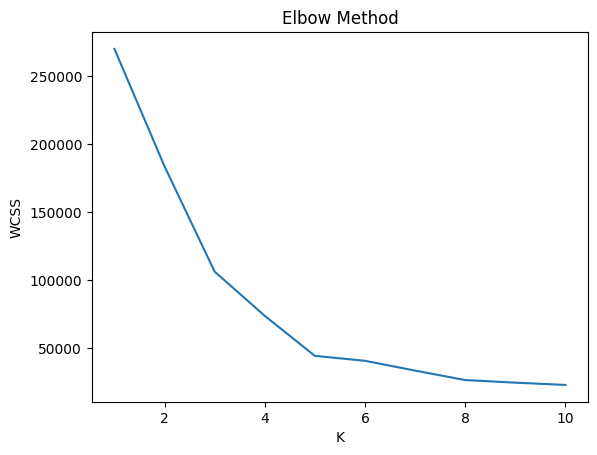

In [27]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

In [28]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
df['Cluster'] = kmeans.fit_predict(X)

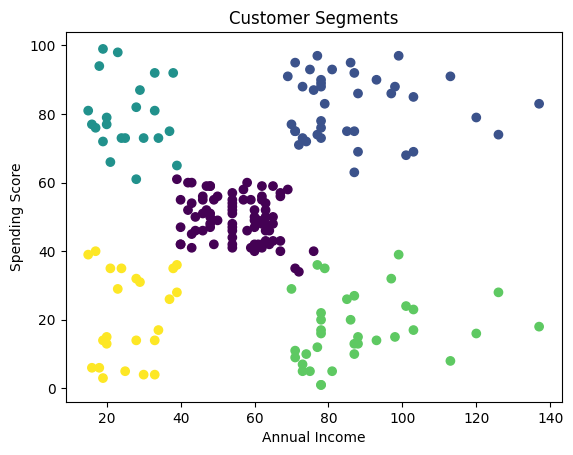

In [31]:
plt.scatter(X['Annual Income (k$)'],X['Spending Score (1-100)'], c = df['Cluster'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segments')
plt.show()

In [34]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [39]:
df.groupby('Cluster').mean(numeric_only = True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [46]:
def label_cluster(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 70:
        return 'Premium'
    elif row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] < 40:
        return 'Potential'
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] > 70:
        return 'Impulse'
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] < 40:
        return 'Budget'
    else:
        return "Average"

df['Customer Type'] = df.apply(label_cluster, axis = 1)

In [48]:
df['Customer Type'] = df['Cluster Type']

In [50]:
df.drop('Cluster Type', axis = 1, inplace = True)

In [51]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Customer Type
0,1,Male,19,15,39,4,Budget
1,2,Male,21,15,81,2,Impulse
2,3,Female,20,16,6,4,Budget
3,4,Female,23,16,77,2,Impulse
4,5,Female,31,17,40,4,Average
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,Premium
196,197,Female,45,126,28,3,Potential
197,198,Male,32,126,74,1,Premium
198,199,Male,32,137,18,3,Potential


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

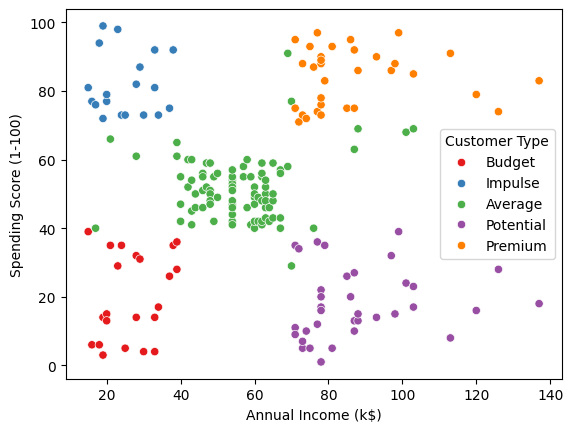

In [53]:
sns.scatterplot(
    x = "Annual Income (k$)",
    y = 'Spending Score (1-100)',
    hue='Customer Type',
    data = df,
    palette = 'Set1'
)

In [54]:
df.to_excel("Customer Segmentation.xlsx", index = False)